In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#c=skycoords()
dpi=300
size=12
labelsize=6
axislabelsize=5
ticksize=6
titlesize=16
msize=1
linewidth=2.0
cmap='Reds'
df=pd.read_csv("datasummary.csv")
#df

In [2]:

l=df["l"].to_numpy()
b=df["b"].to_numpy()
distance=df["distance(pc)"].to_numpy()
id=df["Identifier"].to_numpy()
CRILAlpha=df["CRI L Alpha"].to_numpy()
CRIR=df["CRI R"].to_numpy()
CRIK=df["CRI K"].to_numpy()
c=SkyCoord(l=l*u.degree,b=b*u.degree,frame='galactic')

#ra_rad=c.ra.wrap_at(180*u.deg).radian
#dec_rad=c.dec.radian



ls=359.94423568
bs=-00.04616002
distances=8.2e3

cs=SkyCoord(l=ls*u.degree,b=bs*u.degree,frame='galactic')


cp=SkyCoord(l=90*u.degree,b=90*u.degree,frame='galactic')


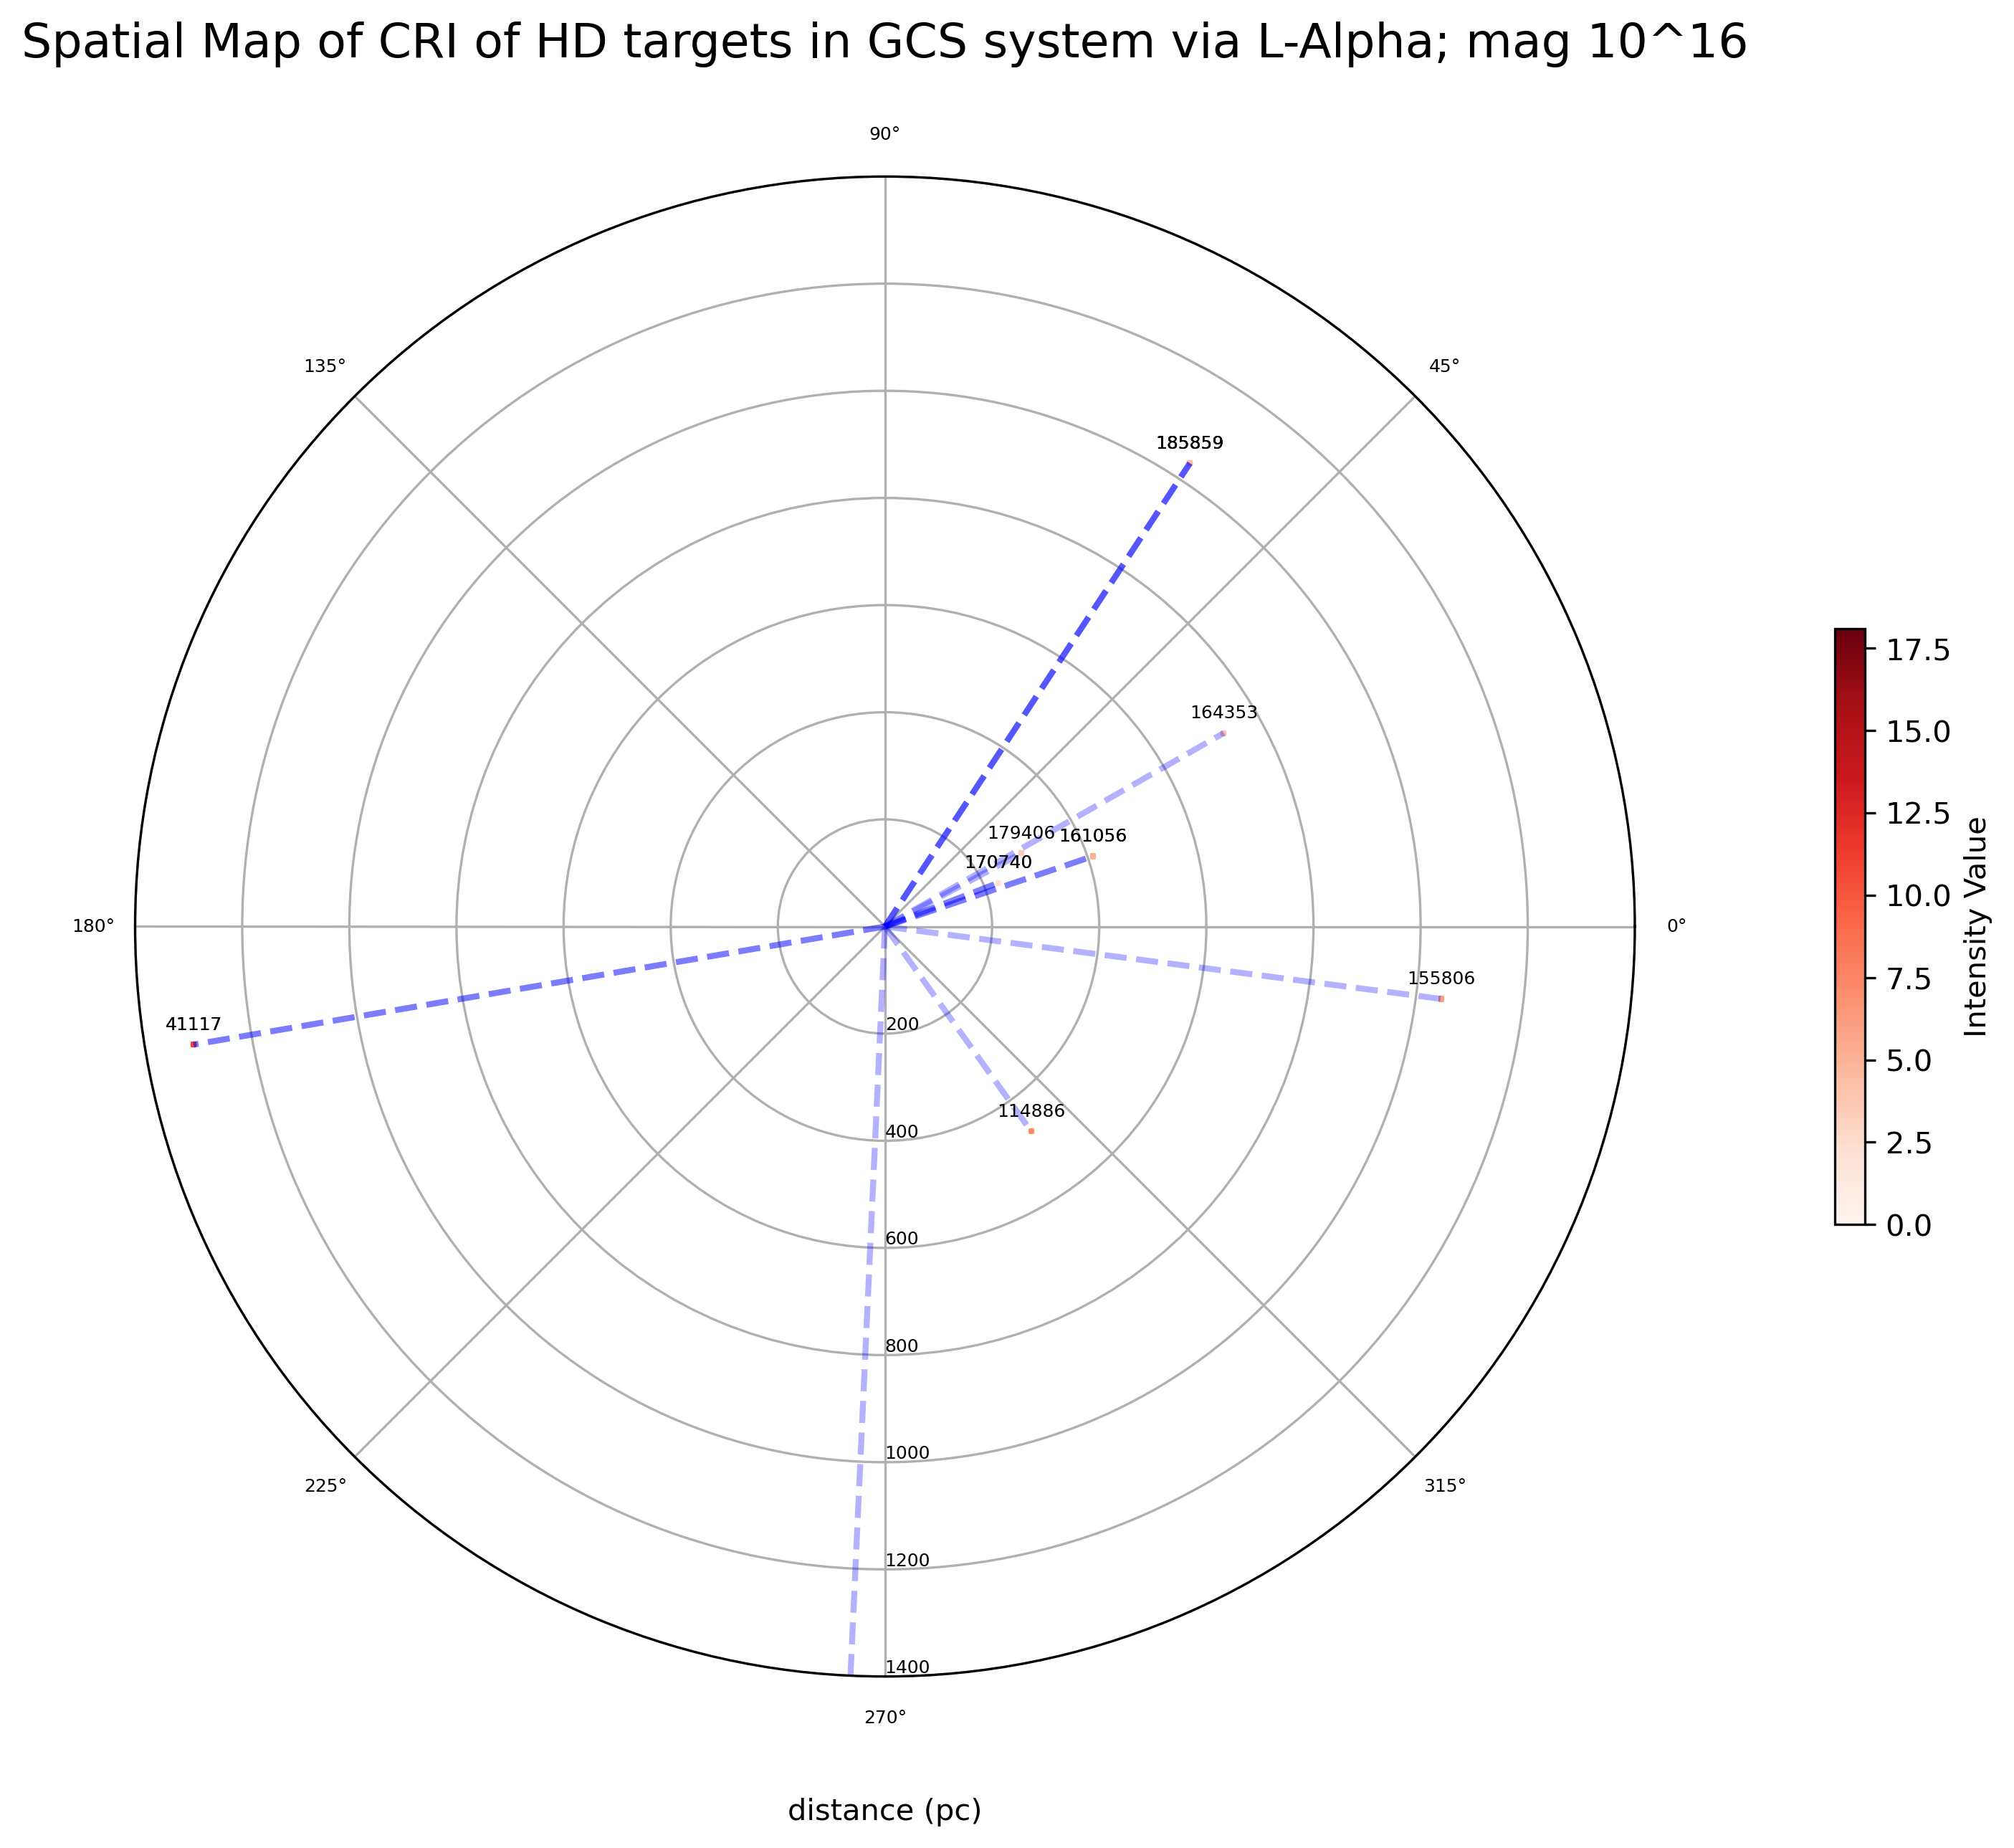

In [3]:
magnitude=np.nan_to_num(CRILAlpha,nan=0)
#print(magnitude)
min=np.min(magnitude)
max=np.max(magnitude)

#print(CRICox)
fig,ax=plt.subplots(figsize=(size,size),subplot_kw=dict(projection="polar"),dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via L-Alpha; mag 10^16",pad=40,fontsize=titlesize)
ax.tick_params(axis='both',labelsize=ticksize)
ax.grid(True)


ax.scatter(cs.l.radian,distances,s=30,marker='*',c='orange')
ax.annotate("Sagittarius A*", (cs.l.radian,distances),fontsize=4,textcoords='offset points',xytext=(0,0))
ax.scatter(cp.l.radian,2000,marker='d',c='red',s=70)
ax.set_ylabel("distance (pc)",va="bottom",rotation=0,ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

a=ax.scatter(c.l.radian,distance,s=msize,c=magnitude*1e16,cmap=cmap,marker="s")
plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1,shrink=0.3)


for r in range(len(id)):
    if magnitude[r]==0:
        continue
    ax.vlines(c.l.radian[r],0,distance[r],linewidth=linewidth,linestyle='--',color='blue',alpha=0.3)
    ax.annotate(f"{id[r][2:]}",(c.l[r].radian,distance[r]),fontsize=labelsize,textcoords='offset points',xytext=(0,5),ha='center')

    
ax.set_rmax(1400.0) # Set maximum radius


fig.savefig("galacticmap L=alpha.png",format='png',dpi='figure')

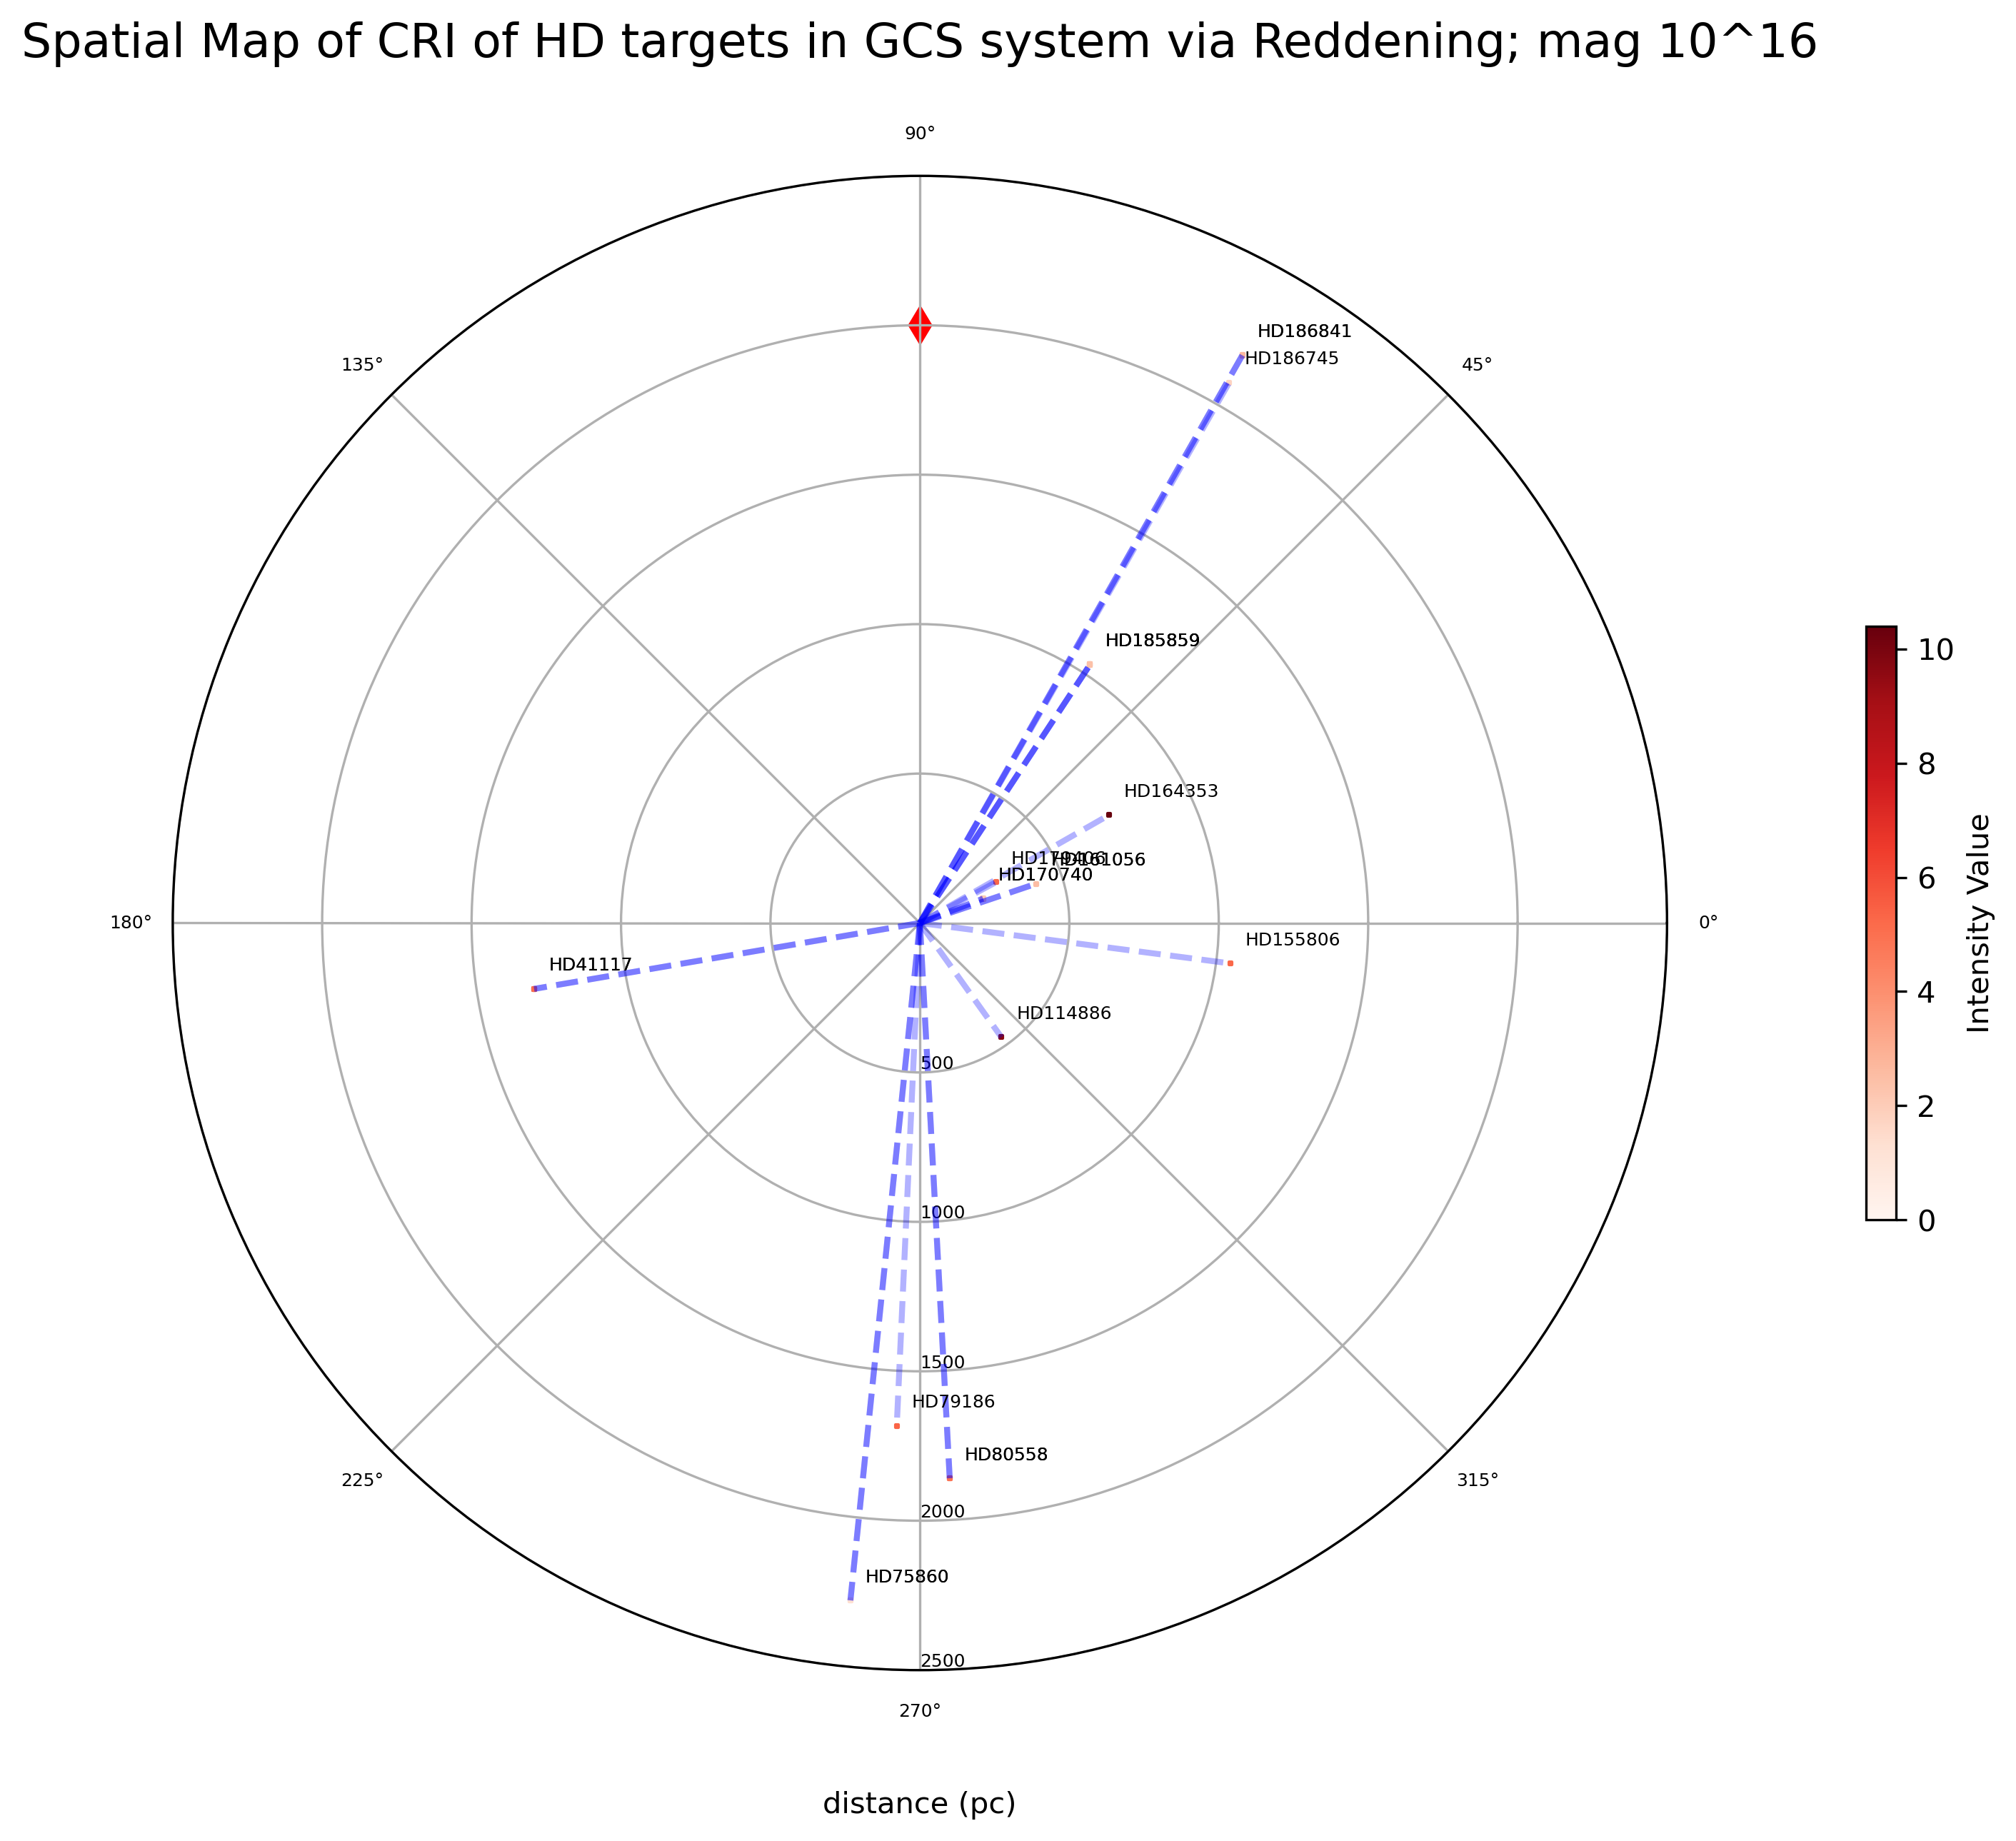

In [4]:
magnitude=np.nan_to_num(CRIR,nan=0)
#print(magnitude)
min=np.min(magnitude)
max=np.max(magnitude)

#print(CRICox)
fig,ax=plt.subplots(figsize=(size,size),subplot_kw=dict(projection="polar"),dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via Reddening; mag 10^16",pad=40,fontsize=titlesize)
ax.tick_params(axis='both',labelsize=ticksize)
ax.grid(True)


ax.scatter(cs.l.radian,distances,s=30,marker='*',c='orange')
ax.annotate("Sagittarius A*", (cs.l.radian,distances),fontsize=4,textcoords='offset points',xytext=(0,0))
ax.scatter(cp.l.radian,2000,marker='d',c='red',s=70)
ax.set_ylabel("distance (pc)",va="bottom",rotation=0,ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

a=ax.scatter(c.l.radian,distance,s=msize,c=magnitude*1e16,cmap=cmap,marker="s")
plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1,shrink=0.3)


"""
for r in range(len(id)):
    if magnitude[r]==0:
        continue
    ax.vlines(c.l.radian[r],0,distance[r],linewidth=0.1,linestyle='-',color='blue',alpha=0.3)
    ax.annotate(f"{id[r]}",(c.l[r].radian,distance[r]),fontsize=labelsize,textcoords='offset points',xytext=(0,0))
"""

for r in range(len(id)):
    if magnitude[r] == 0:
        continue
    ax.vlines(c.l.radian[r], 0, distance[r], linewidth=linewidth, linestyle='--', color='blue', alpha=0.3)
    
    # ADDED PADDING: 
    # xytext=(5, 5) moves text 5 points right and 5 points up from the dot
    # ha='left' and va='bottom' ensures the text doesn't sit directly on the point
    ax.annotate(f"{id[r]}", 
                (c.l[r].radian, distance[r]), 
                fontsize=labelsize, 
                textcoords='offset points', 
                xytext=(5, 5),   # <--- Change these values to increase/decrease padding
                ha='left',      # <--- Horizontal alignment
                va='bottom')    # <--- Vertical alignment

ax.set_rmax(2500.0) # Set maximum radius
fig.savefig("galacticmap Red.png",format='png',dpi='figure')


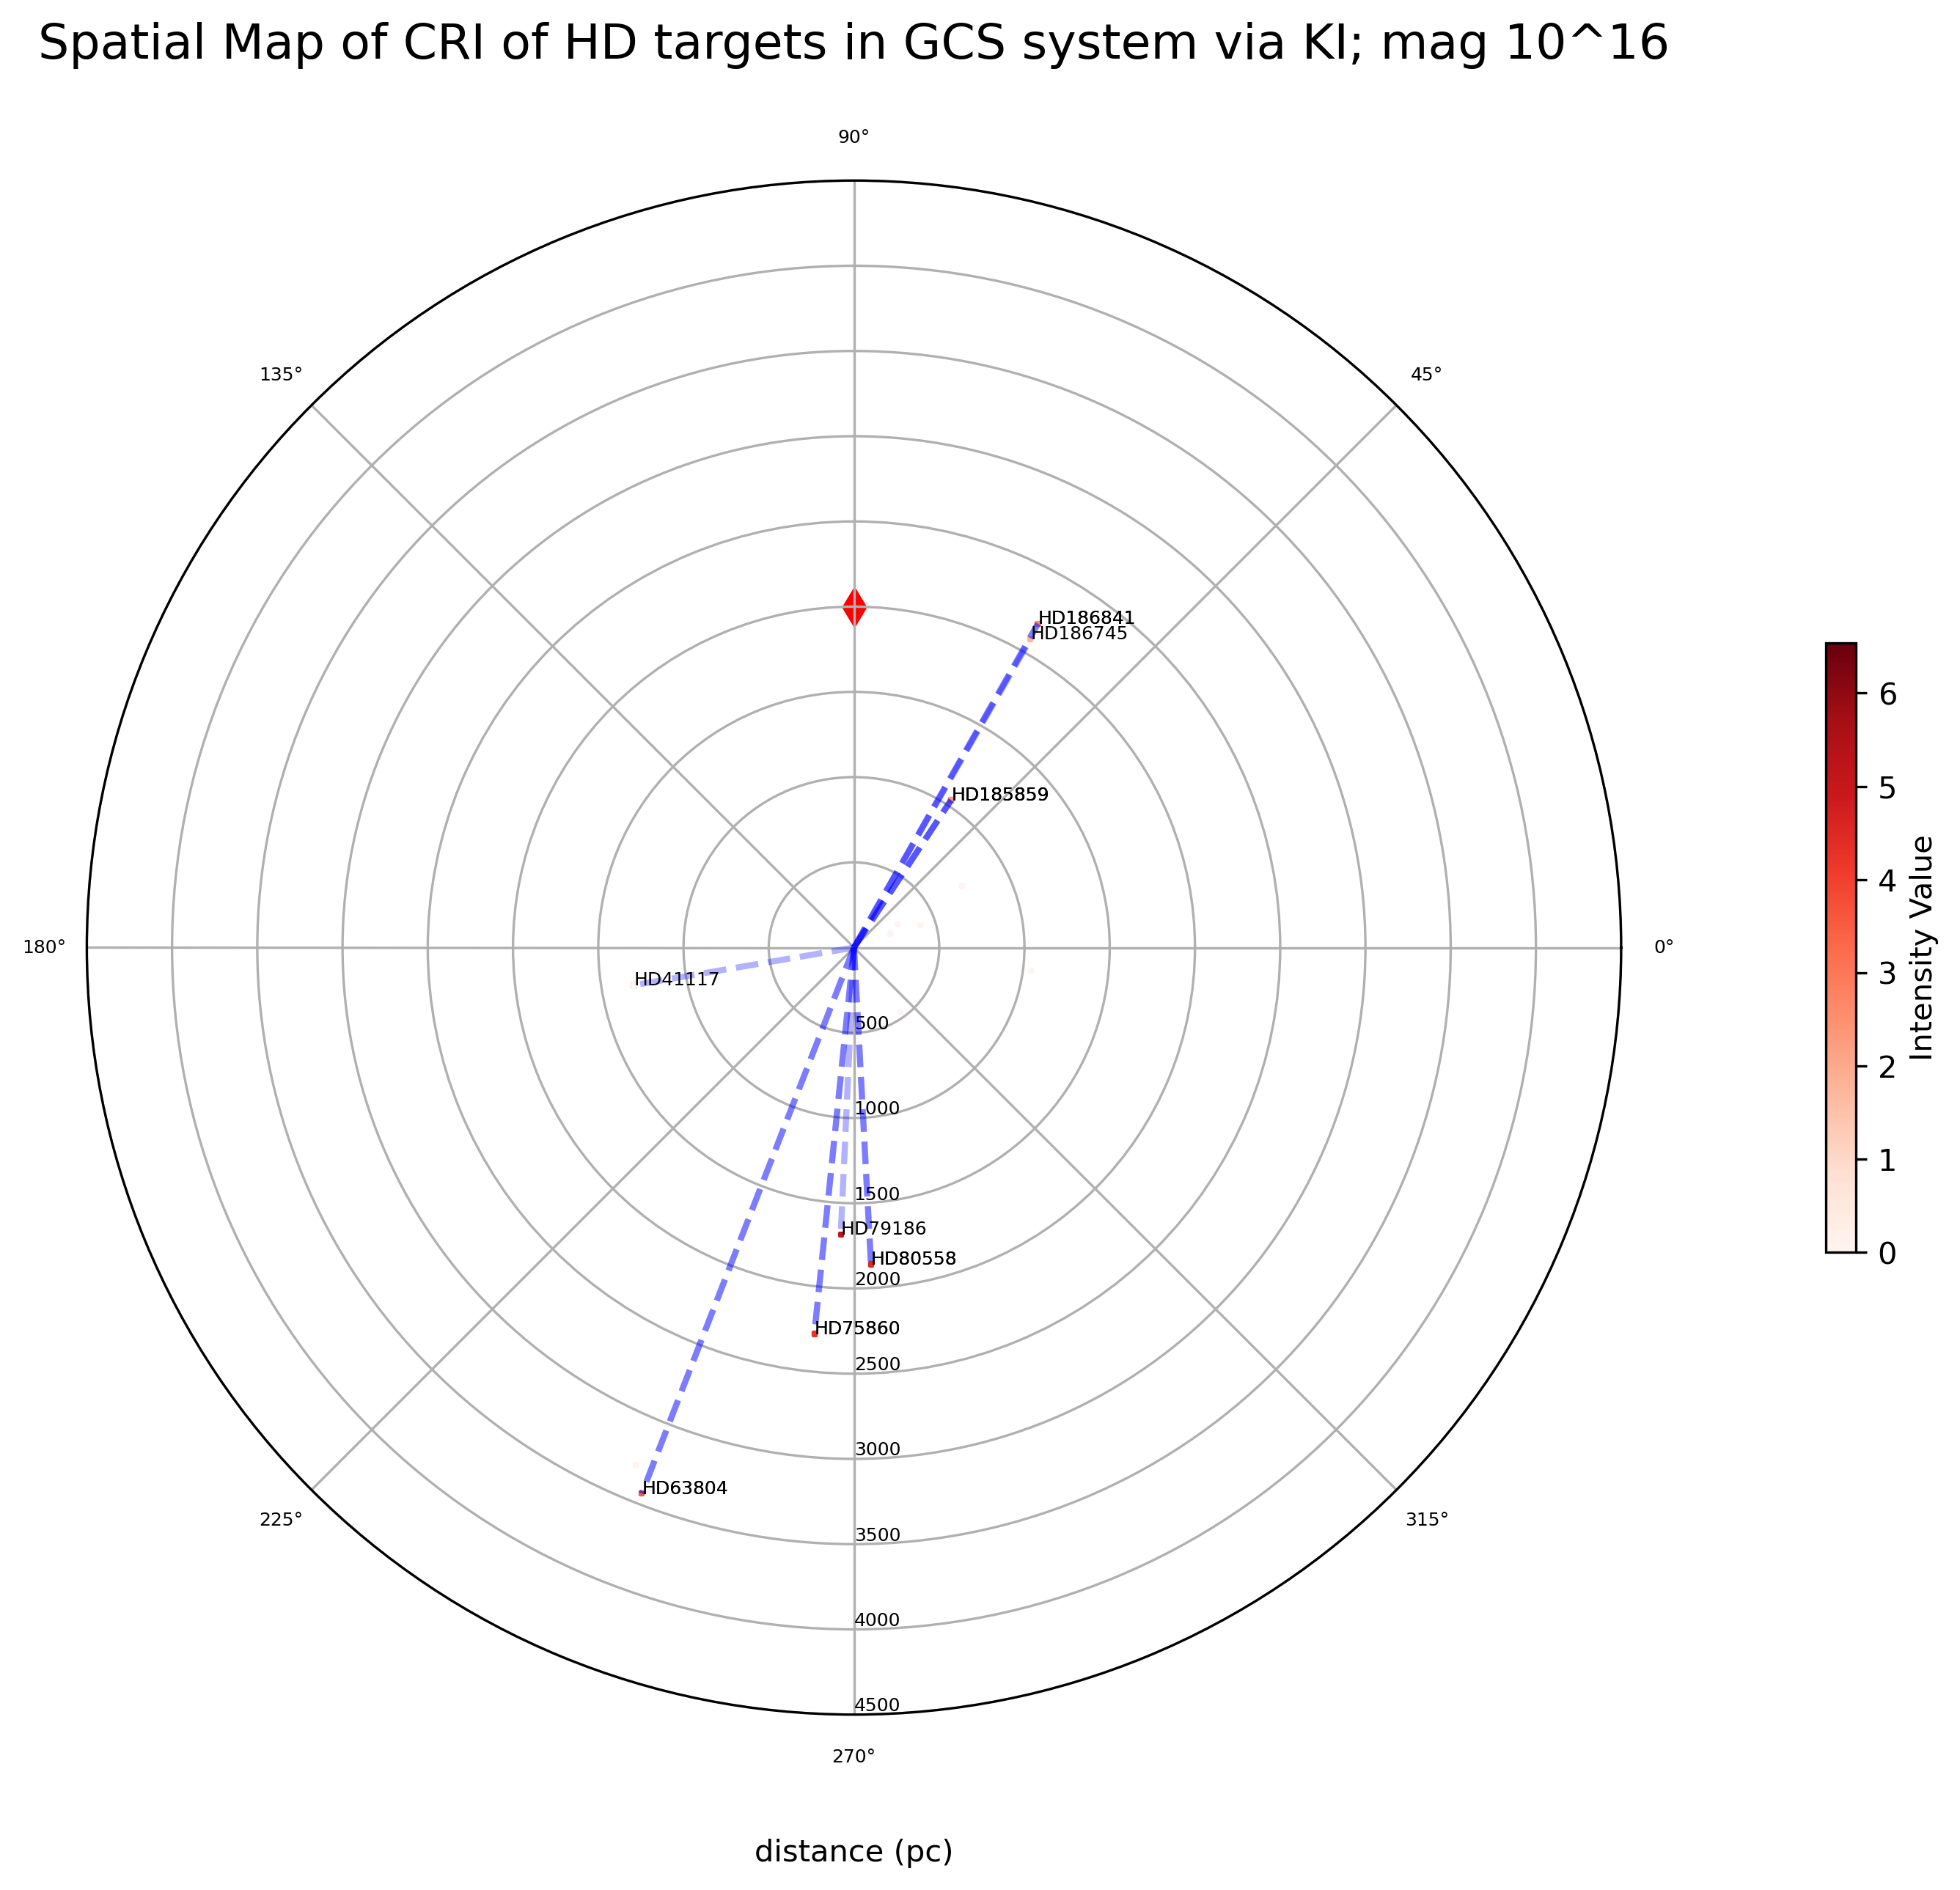

In [5]:
magnitude=np.nan_to_num(CRIK,nan=0)

min=np.min(magnitude)
max=np.max(magnitude)

fig,ax=plt.subplots(figsize=(size,size),subplot_kw=dict(projection="polar"),dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via KI; mag 10^16",pad=40,fontsize=titlesize)
ax.tick_params(axis='both',labelsize=ticksize)
ax.grid(True)

ax.scatter(cs.l.radian,distances,s=30,marker='*',c='orange')
ax.annotate("Sagittarius A*", (cs.l.radian,distances),fontsize=4,textcoords='offset points',xytext=(0,0))
ax.scatter(cp.l.radian,2000,marker='d',c='red',s=70)
ax.set_ylabel("distance (pc)",va="bottom",rotation=0,ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

a=ax.scatter(c.l.radian,distance,s=msize,c=magnitude*1e16,cmap=cmap,marker="s")
plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1,shrink=0.3)





for r in range(len(id)):
    if magnitude[r]==0:
        continue
    ax.vlines(c.l.radian[r],0,distance[r],linewidth=linewidth,linestyle='--',color='blue',alpha=0.3)
    ax.annotate(f"{id[r]}",(c.l[r].radian,distance[r]),fontsize=labelsize,textcoords='offset points',xytext=(0,0))
    
ax.set_rmax(4500.0) # Set maximum radius

fig.savefig("galacticmap K.png",format='png',dpi='figure')